In [62]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import datetime
import json

In [63]:
com_port1="/dev/tty.usbmodem1101"
tag1=Tag(com_port1)
ip_port_out = tag1.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag1.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag1.get_mac_wifi())

com_port2="/dev/tty.usbmodem1201"
tag2=Tag(com_port2)
ip_port_out = tag2.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag2.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag2.get_mac_wifi())


{'net': 'up', 'ip': '10.234.62.169', 'port': 3333, 'rssi': -38}
B4:3A:45:8A:BC:30
{'net': 'up', 'ip': '10.234.62.216', 'port': 3333, 'rssi': -34}
58:E6:C5:01:08:CC


In [64]:
# Queue BEFORE arming. esync makes the firmware suspend the radio within
# ESYNC_WIFI_QUIET_MS of acking, so anything sent after it never lands.
tag1.queue_adc_read_wifi(810)
tag2.queue_mpp_wifi(1)

tag1.listen_esync_wifi()
tag2.listen_esync_wifi()

# Blocks until each radio is back: either the edge fired, or the firmware
# gave up after ESYNC_WIFI_TIMEOUT_MS.
tag1.reconnect_wifi()
tag2.reconnect_wifi()

# The replies were buffered in RAM while the radio was down; pull them.
# tag2 runs the sweep and only answers with a status line -- the trace worth
# plotting is tag1's adc reply, recorded across tag2's sweep.
mpp_data  = tag1.fetch_queued_wifi()   # {"info":"adc",...,"data":"..."}
sweep_ack = tag2.fetch_queued_wifi()   # {"info":"mpp",...,"ok":1}

for name, data in (("tag1", mpp_data), ("tag2", sweep_ack)):
    if data.get("pending") == 0:
        raise Exception(f"{name}: no queued reply -- esync window timed out")

print("tag1 edge:", tag1.esync_report_wifi())
print("tag2 edge:", tag2.esync_report_wifi())
print("tag2 sweep:", sweep_ack)


b'q:queued, adc_810\n' 	 b'q:queued, adc_810\n'
b'q:queued, mpp_1\n' 	 b'q:queued, mpp_1\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
tag1 edge: {'info': 'esync', 'edge': 'rise', 't_us': 874862846, 'low_us': 4578, 'min_mv': 0.916, 'base_mv': 294.881}
tag2 edge: {'info': 'esync', 'edge': 'rise', 't_us': 772772547, 'low_us': 2676, 'min_mv': 1.221, 'base_mv': 486.534}
tag2 sweep: {'info': 'mpp', 'ch': 8, 'passes': 1, 'ok': 1}


270.085
data is fine
segment 0 [360, 435): 75 readings
segment 1 [435, 510): 75 readings
segment 2 [510, 585): 75 readings
segment 3 [585, 660): 75 readings
segment 4 [660, 735): 75 readings
segment 5 [735, 810): 75 readings


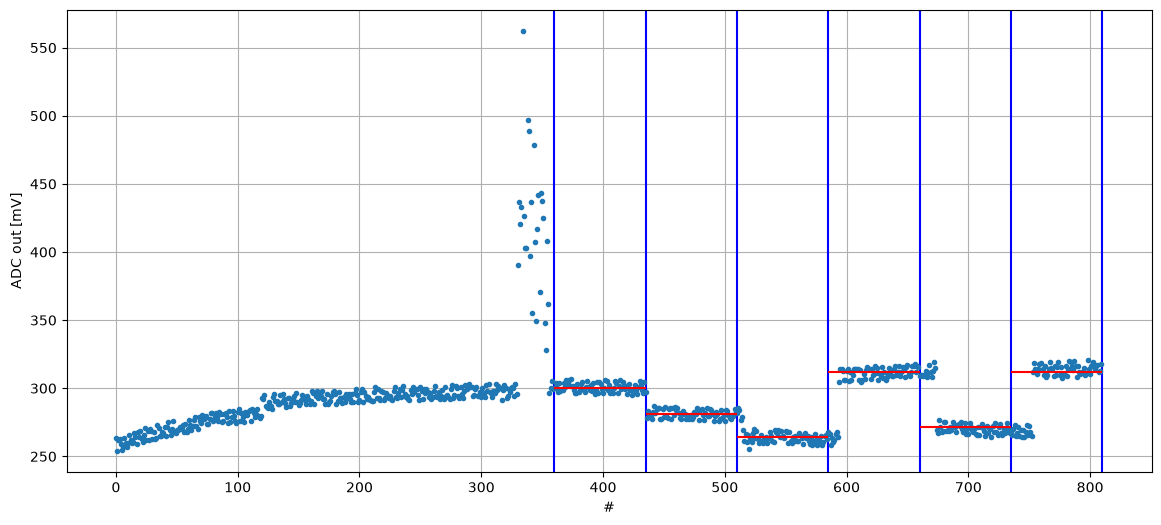

2026-08-27 13:11:46


In [65]:
def plotMPPSegments(data, seg_size=75, n_segments=6):
    """
    Plot an adc reply and split its tail into n_segments vertical segments of
    seg_size samples, counted from the back of the trace. Whatever comes before
    the first boundary is still plotted, just not segmented.
    """
    if isinstance(data, dict):
        data = data['data']
    if isinstance(data, str):
        data = list(map(float, data.split(',')))
        
    voltage = np.asarray(data, dtype=float)
    print(np.median(voltage[:100]))
    if np.median(voltage[:100])<5:
        print("Bad data")
    else:
        print("data is fine")
    
    idx = np.arange(len(voltage))

    # Boundaries walked backwards from the last sample, then flipped so the
    # segments come out in ascending index order. Clamped at 0 for short traces.
    edges = sorted({max(len(voltage) - seg_size * i, 0) for i in range(n_segments + 1)})

    plt.figure(figsize=(14, 6))
    for e in edges:
        plt.axvline(x=e, color='b')

    plt.plot(idx, voltage, '.')

    for seg, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        in_segment = (idx >= left) & (idx < right)
        print(f"segment {seg} [{left}, {right}): {np.count_nonzero(in_segment)} readings")
        if not np.any(in_segment):
            continue
        plt.hlines(np.median(voltage[in_segment]), left, right, color='r', zorder=3)

    plt.xlabel("#")
    plt.ylabel("ADC out [mV]")
    plt.grid()
    # plt.ylim([150,200])
    plt.show()



plotMPPSegments(mpp_data)



print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

